In [4]:
from datasets import load_dataset
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("Environment ready")

Environment ready


In [5]:
from datasets import load_dataset

ds = load_dataset(
    "ufldl-stanford/svhn",
    "full_numbers"
)

print(ds)

DatasetDict({
    train: Dataset({
        features: ['image', 'digits'],
        num_rows: 33402
    })
    test: Dataset({
        features: ['image', 'digits'],
        num_rows: 13068
    })
    extra: Dataset({
        features: ['image', 'digits'],
        num_rows: 202353
    })
})


In [3]:
print(ds["train"].features)

{'image': Image(mode=None, decode=True), 'digits': {'bbox': List(List(Value('int32'), length=4)), 'label': List(ClassLabel(names=['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']))}}


In [4]:
print(ds["train"][0])

{'image': <PIL.PngImagePlugin.PngImageFile image mode=RGB size=107x46 at 0x1BB57D0DC90>, 'digits': {'bbox': [[38, 1, 21, 40], [57, 3, 16, 40]], 'label': [4, 6]}}


In [5]:
train = ds["train"]
test = ds["test"]

print(f"Training images: {len(train):,}")
print(f"Test images:     {len(test):,}")

print(f"\nTraining columns: {train.column_names}")

Training images: 33,402
Test images:     13,068

Training columns: ['image', 'digits']


In [6]:
train_digits_per_image = [
    len(example["digits"]["label"])
    for example in train
]

test_digits_per_image = [
    len(example["digits"]["label"])
    for example in test
]

print("Training digit-count statistics:")
print(pd.Series(train_digits_per_image).describe())

print("\nTest digit-count statistics:")
print(pd.Series(test_digits_per_image).describe())

Training digit-count statistics:
count    33402.000000
mean         2.193192
std          0.742503
min          1.000000
25%          2.000000
50%          2.000000
75%          3.000000
max          6.000000
dtype: float64

Test digit-count statistics:
count    13068.000000
mean         1.992042
std          0.628716
min          1.000000
25%          2.000000
50%          2.000000
75%          2.000000
max          5.000000
dtype: float64


In [7]:
print("Dataset columns:")
print(train.column_names)

print("\nDataset features:")
for name, feature in train.features.items():
    print(f"\n{name}:")
    print(feature)

Dataset columns:
['image', 'digits']

Dataset features:

image:
Image(mode=None, decode=True)

digits:
{'bbox': List(List(Value('int32'), length=4)), 'label': List(ClassLabel(names=['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']))}


In [8]:
example = train[0]

print("\nFirst example:")
print(example)


First example:
{'image': <PIL.PngImagePlugin.PngImageFile image mode=RGB size=107x46 at 0x1BB57D73550>, 'digits': {'bbox': [[38, 1, 21, 40], [57, 3, 16, 40]], 'label': [4, 6]}}


In [9]:
print("\nImage:")
print("Type:", type(example["image"]))
print("Mode:", example["image"].mode)
print("Size:", example["image"].size)

print("\nDigits:")
print("Keys:", example["digits"].keys())
print("Labels:", example["digits"]["label"])
print("Bounding boxes:", example["digits"]["bbox"])


Image:
Type: <class 'PIL.PngImagePlugin.PngImageFile'>
Mode: RGB
Size: (107, 46)

Digits:
Keys: dict_keys(['bbox', 'label'])
Labels: [4, 6]
Bounding boxes: [[38, 1, 21, 40], [57, 3, 16, 40]]


##### Digit-Class Distribution

In [10]:
from collections import Counter

train_labels = []

for example in train:
    train_labels.extend(example["digits"]["label"])

label_counts = Counter(train_labels)

label_counts = {
    int(label): count
    for label, count in sorted(label_counts.items())
}

label_counts

{0: 4948,
 1: 13861,
 2: 10585,
 3: 8497,
 4: 7458,
 5: 6882,
 6: 5727,
 7: 5595,
 8: 5045,
 9: 4659}

In [11]:
total_labels = sum(label_counts.values())

label_distribution = pd.DataFrame({
    "digit": list(label_counts.keys()),
    "count": list(label_counts.values()),
})

label_distribution["percentage"] = (
    label_distribution["count"] / total_labels * 100
)

label_distribution

,digit,count,percentage
0,0,4948,6.754303
1,1,13861,18.921059
2,2,10585,14.449131
3,3,8497,11.598892
4,4,7458,10.180597
5,5,6882,9.394324
6,6,5727,7.817683
7,7,5595,7.637495
8,8,5045,6.886714
9,9,4659,6.359802


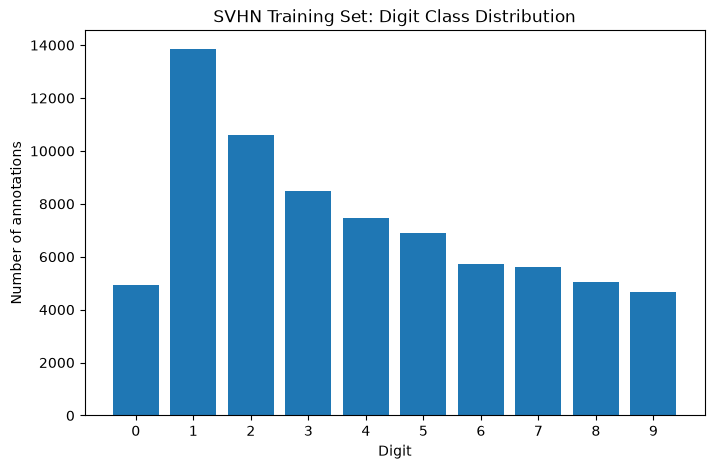

In [12]:
plt.figure(figsize=(8, 5))

plt.bar(
    label_distribution["digit"].astype(str),
    label_distribution["count"]
)

plt.xlabel("Digit")
plt.ylabel("Number of annotations")
plt.title("SVHN Training Set: Digit Class Distribution")

plt.show()

##### Analyze the bounding boxes

In [13]:
bbox_records = []

for example in train:
    image = example["image"]
    width, height = image.size

    for bbox, label in zip(
        example["digits"]["bbox"],
        example["digits"]["label"]
    ):
        x, y, bbox_width, bbox_height = bbox

        bbox_records.append({
            "image_width": width,
            "image_height": height,
            "x": x,
            "y": y,
            "bbox_width": bbox_width,
            "bbox_height": bbox_height,
            "label": int(label),
        })

bbox_df = pd.DataFrame(bbox_records)

print(f"Total bounding boxes: {len(bbox_df):,}")
bbox_df.head()

Total bounding boxes: 73,257


,image_width,image_height,x,y,bbox_width,bbox_height,label
0,107,46,38,1,21,40,4
1,107,46,57,3,16,40,6
2,61,31,21,4,12,23,7
3,61,31,31,5,10,23,1
4,67,31,24,4,10,23,2


In [14]:
bbox_df[
    ["image_width", "image_height", "bbox_width", "bbox_height"]
].describe()

,image_width,image_height,bbox_width,bbox_height
count,73257.000000,73257.000000,73257.000000,73257.000000
mean,133.649672,58.332460,16.650491,33.861310
std,83.342700,36.970655,10.681429,18.601294
min,25.000000,12.000000,1.000000,9.000000
25%,74.000000,33.000000,10.000000,21.000000
50%,108.000000,48.000000,14.000000,29.000000
75%,167.000000,74.000000,21.000000,41.000000
max,876.000000,501.000000,207.000000,403.000000


In [15]:
bbox_df["bbox_area"] = (
    bbox_df["bbox_width"] * bbox_df["bbox_height"]
)

bbox_df["image_area"] = (
    bbox_df["image_width"] * bbox_df["image_height"]
)

bbox_df["relative_bbox_area"] = (
    bbox_df["bbox_area"] / bbox_df["image_area"]
)

bbox_df["bbox_aspect_ratio"] = (
    bbox_df["bbox_width"] / bbox_df["bbox_height"]
)

bbox_df[
    ["relative_bbox_area", "bbox_aspect_ratio"]
].describe()

,relative_bbox_area,bbox_aspect_ratio
count,73257.000000,73257.000000
mean,0.089787,0.490687
std,0.046705,0.135681
min,0.001633,0.034483
25%,0.055142,0.400000
50%,0.084722,0.483871
75%,0.118227,0.575758
max,0.490937,1.928571


##### Visual Inspection

In [16]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches


def show_sample(dataset, index):
    example = dataset[index]

    image = example["image"]
    boxes = example["digits"]["bbox"]
    labels = example["digits"]["label"]

    fig, ax = plt.subplots(figsize=(10, 5))

    ax.imshow(image)

    for bbox, label in zip(boxes, labels):
        x, y, width, height = bbox

        rect = patches.Rectangle(
            (x, y),
            width,
            height,
            fill=False,
            linewidth=2,
        )

        ax.add_patch(rect)

        ax.text(
            x,
            y - 2,
            str(label),
            fontsize=10,
            bbox=dict(
                facecolor="white",
                alpha=0.7,
                edgecolor="none",
            ),
        )

    ax.set_title(
        f"SVHN training example {index} "
        f"({len(labels)} digit(s))"
    )

    ax.axis("off")
    plt.show()

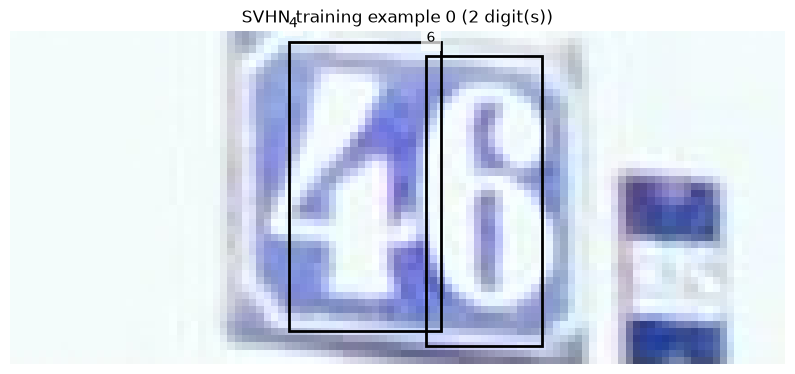

In [17]:
show_sample(train, 0)

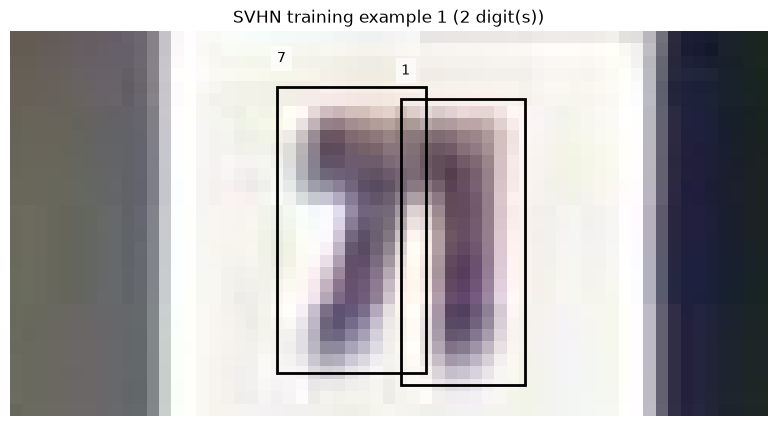

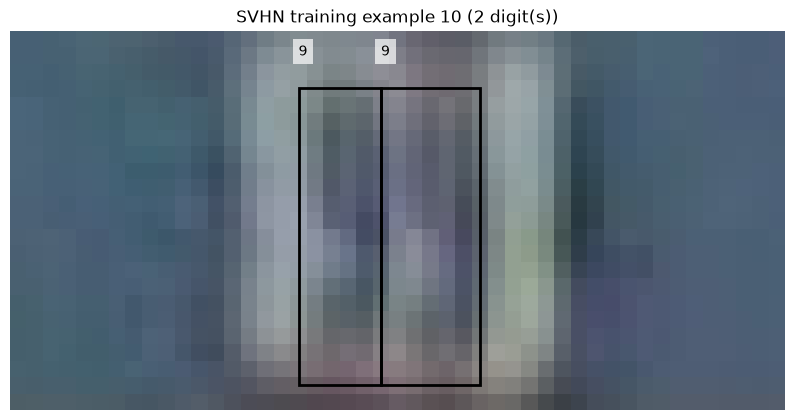

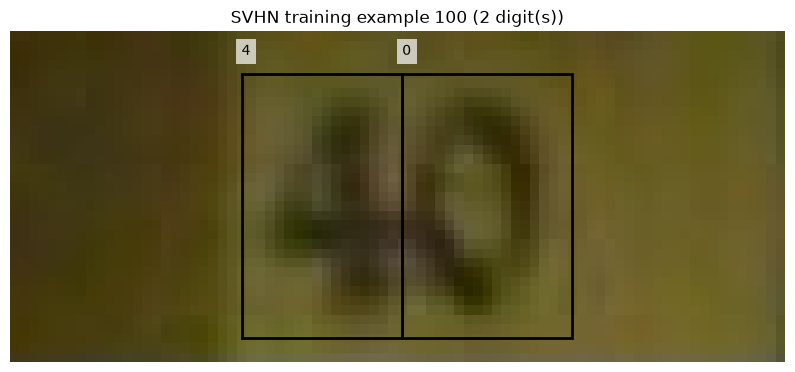

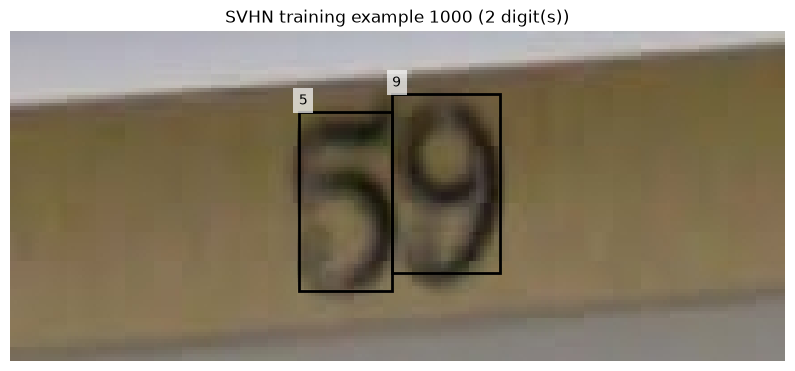

In [18]:
for index in [1, 10, 100, 1000]:
    show_sample(train, index)

### SVHN `full_numbers` Dataset — Initial Understanding

#### Dataset overview

This project uses the `full_numbers` configuration of the
`ufldl-stanford/svhn` dataset from Hugging Face.

The `full_numbers` configuration contains street-number images
together with annotations for the individual digits appearing in
each image.

The primary task for this project is **multi-object digit detection**:
for each image, the model should identify the individual digits and
predict both their class and location.

---

#### Dataset splits

The dataset contains three splits:

| Split | Number of images | Initial use |
|---|---:|---|
| Train | 33,402 | Model training |
| Test | 13,068 | Final evaluation |
| Extra | 202,353 | Not used initially |

The initial experiments will use the `train` and `test` splits.
The `extra` split will not be included in the baseline experiments.

---

#### Dataset structure

Each example contains two top-level fields:

- `image`
- `digits`

The `image` field contains the actual RGB image.

The `digits` field is a nested structure containing:

- `bbox` — bounding-box annotations for the individual digits
- `label` — the digit class for each bounding box

Therefore, one image can contain multiple digit objects.

For example, one observed training example contains:

```text
Image:
RGB
107 × 46 pixels

Labels:
[4, 6]

Bounding boxes:
[
    [38, 1, 21, 40],
    [57, 3, 16, 40]
]

### Exploratory Data Analysis

This section examines the characteristics of the SVHN `full_numbers`
training and test sets. The analysis focuses on:

- number of digits per image
- digit-class distribution
- image dimensions
- bounding-box dimensions
- bounding-box proportions
- qualitative examples of the annotations

#### Number of digits per image

The number of annotated digits varies between images.

For the training set:

- Number of images: 33,402
- Mean number of digits per image: 2.19
- Median: 2
- Minimum: 1
- Maximum: 6

For the test set:

- Number of images: 13,068
- Mean number of digits per image: 1.99
- Median: 2
- Minimum: 1
- Maximum: 5

Most images therefore contain a relatively small number of individual
digit objects, although the number of objects varies between images.

#### Digit-class distribution

The training set contains 73,257 annotated digit objects.

The distribution across the ten digit classes is not uniform:

| Digit | Annotations | Percentage |
|---:|---:|---:|
| 0 | 4,948 | 6.75% |
| 1 | 13,861 | 18.92% |
| 2 | 10,585 | 14.45% |
| 3 | 8,497 | 11.60% |
| 4 | 7,458 | 10.18% |
| 5 | 6,882 | 9.39% |
| 6 | 5,727 | 7.82% |
| 7 | 5,595 | 7.64% |
| 8 | 5,045 | 6.89% |
| 9 | 4,659 | 6.36% |

Digit `1` is the most frequent class, while digit `9` is the least
frequent in the training annotations.

The class distribution will be considered when interpreting
per-class detection results later in the project.

#### Image and bounding-box characteristics

The training set contains 73,257 digit bounding boxes.

The observed image dimensions are variable:

- Width: 25–876 pixels
- Height: 12–501 pixels
- Median width: 108 pixels
- Median height: 48 pixels

The bounding-box dimensions are also variable:

- Median bounding-box width: 14 pixels
- Median bounding-box height: 29 pixels
- Mean bounding-box width: 16.65 pixels
- Mean bounding-box height: 33.86 pixels

The median bounding-box area corresponds to approximately 8.47% of
the corresponding image area.

The bounding-box aspect ratio has a median of approximately 0.48,
indicating that the typical digit bounding box is taller than it is
wide.

These characteristics indicate substantial variation in both image
size and object size, which will need to be handled by the
preprocessing pipeline.

In [19]:
image_sizes = pd.DataFrame(
    [
        {
            "width": example["image"].size[0],
            "height": example["image"].size[1],
        }
        for example in train
    ]
)

image_sizes.describe()

,width,height
count,33402.000000,33402.000000
mean,128.284983,57.213011
std,80.546218,36.179696
min,25.000000,12.000000
25%,72.000000,33.000000
50%,104.000000,47.000000
75%,158.000000,71.000000
max,876.000000,501.000000


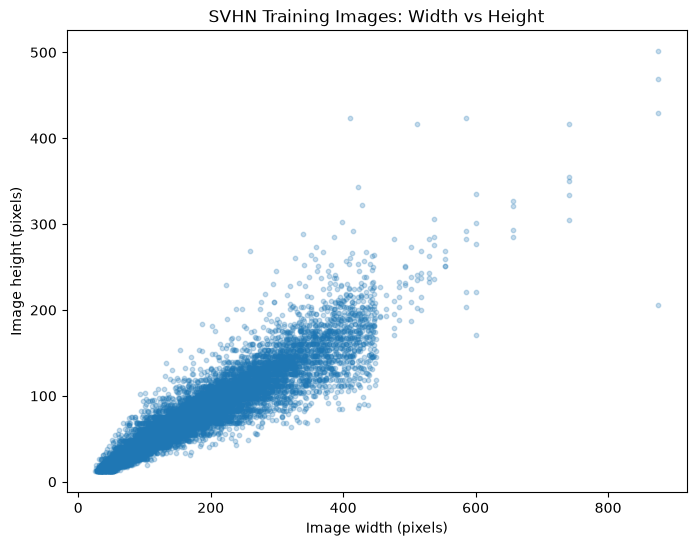

In [20]:
plt.figure(figsize=(8, 6))

plt.scatter(
    image_sizes["width"],
    image_sizes["height"],
    alpha=0.25,
    s=10
)

plt.xlabel("Image width (pixels)")
plt.ylabel("Image height (pixels)")
plt.title("SVHN Training Images: Width vs Height")

plt.show()

#### Image-size analysis

The training images have highly variable spatial dimensions.

The image width ranges from 25 to 876 pixels, while image height ranges
from 12 to 501 pixels. The median image size is 104 × 47 pixels and
the mean is approximately 128 × 57 pixels.

The width-versus-height visualization shows that most images are
concentrated in the smaller-size region, with a smaller number of
substantially larger images.

This variation means that the preprocessing pipeline must handle
different image dimensions before the images are passed to the object
detection model.

Importantly, any spatial transformation applied to an image must also
be applied consistently to its bounding-box annotations.

In [21]:
from transformers import DetrImageProcessor

processor = DetrImageProcessor.from_pretrained(
    "facebook/detr-resnet-50"
)

print(processor)

DetrImageProcessor {
  "do_convert_annotations": true,
  "do_normalize": true,
  "do_pad": true,
  "do_rescale": true,
  "do_resize": true,
  "format": "coco_detection",
  "image_mean": [
    0.485,
    0.456,
    0.406
  ],
  "image_processor_type": "DetrImageProcessor",
  "image_std": [
    0.229,
    0.224,
    0.225
  ],
  "resample": 2,
  "rescale_factor": 0.00392156862745098,
  "size": {
    "longest_edge": 1333,
    "shortest_edge": 800
  }
}



In [22]:
example = train[0]

image = example["image"]

print("Original image size:", image.size)

processed = processor(images=image, return_tensors="pt")

print("Processed pixel_values shape:", processed["pixel_values"].shape)

print("Pixel mask shape:", processed["pixel_mask"].shape)

Original image size: (107, 46)
Processed pixel_values shape: torch.Size([1, 3, 573, 1332])
Pixel mask shape: torch.Size([1, 573, 1332])


In [23]:
example = train[0]

print("Original:")
print("Image size:", example["image"].size)
print("Boxes:", example["digits"]["bbox"])
print("Labels:", example["digits"]["label"])

Original:
Image size: (107, 46)
Boxes: [[38, 1, 21, 40], [57, 3, 16, 40]]
Labels: [4, 6]


In [24]:
example = train[0]

annotations = []

for bbox, label in zip(
    example["digits"]["bbox"],
    example["digits"]["label"]
):
    annotations.append({
        "bbox": bbox,
        "category_id": label,
        "area": bbox[2] * bbox[3],
        "iscrowd": 0,
    })

target = {
    "image_id": 0,
    "annotations": annotations,
}

processed = processor(
    images=example["image"],
    annotations=target,
    return_tensors="pt",
)

print(processed.keys())
print(processed["pixel_values"].shape)
print(processed["labels"][0])

KeysView({'pixel_mask': tensor([[[1, 1, 1,  ..., 1, 1, 1],
         [1, 1, 1,  ..., 1, 1, 1],
         [1, 1, 1,  ..., 1, 1, 1],
         ...,
         [1, 1, 1,  ..., 1, 1, 1],
         [1, 1, 1,  ..., 1, 1, 1],
         [1, 1, 1,  ..., 1, 1, 1]]]), 'pixel_values': tensor([[[[2.0605, 2.0605, 2.0605,  ..., 2.0434, 2.0434, 2.0434],
          [2.0605, 2.0605, 2.0605,  ..., 2.0434, 2.0434, 2.0434],
          [2.0605, 2.0605, 2.0605,  ..., 2.0434, 2.0434, 2.0434],
          ...,
          [2.0948, 2.0948, 2.0948,  ..., 2.0605, 2.0605, 2.0605],
          [2.0948, 2.0948, 2.0948,  ..., 2.0605, 2.0605, 2.0605],
          [2.0948, 2.0948, 2.0948,  ..., 2.0605, 2.0605, 2.0605]],

         [[2.3936, 2.3936, 2.3936,  ..., 2.3585, 2.3585, 2.3585],
          [2.3936, 2.3936, 2.3936,  ..., 2.3585, 2.3585, 2.3585],
          [2.3936, 2.3936, 2.3936,  ..., 2.3585, 2.3585, 2.3585],
          ...,
          [2.3410, 2.3410, 2.3410,  ..., 2.3235, 2.3235, 2.3235],
          [2.3410, 2.3410, 2.3410,  ..., 

##### Class Mapping

In [25]:
id2label = {
    0: "0",
    1: "1",
    2: "2",
    3: "3",
    4: "4",
    5: "5",
    6: "6",
    7: "7",
    8: "8",
    9: "9",
}

label2id = {
    "0": 0,
    "1": 1,
    "2": 2,
    "3": 3,
    "4": 4,
    "5": 5,
    "6": 6,
    "7": 7,
    "8": 8,
    "9": 9,
}

print(id2label)
print(label2id)

{0: '0', 1: '1', 2: '2', 3: '3', 4: '4', 5: '5', 6: '6', 7: '7', 8: '8', 9: '9'}
{'0': 0, '1': 1, '2': 2, '3': 3, '4': 4, '5': 5, '6': 6, '7': 7, '8': 8, '9': 9}


In [26]:
from transformers import DetrForObjectDetection

model = DetrForObjectDetection.from_pretrained(
    "facebook/detr-resnet-50",
    num_labels=10,
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True,
)

print("Number of labels:", model.config.num_labels)
print("Number of object queries:", model.config.num_queries)

[transformers] You passed `num_labels=10` which is incompatible to the `id2label` map of length `91`.
Loading weights: 100%|██████████| 530/530 [00:00<00:00, 2667.32it/s]
[transformers] DetrForObjectDetection LOAD REPORT from: facebook/detr-resnet-50
Key                                                            | Status     |                                                                                         
---------------------------------------------------------------+------------+-----------------------------------------------------------------------------------------
model.backbone.model.layer1.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                         
model.backbone.model.layer3.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                         
model.backbone.model.layer2.0.downsample.1.num_batches_tracked | UNEXPECTED |    

Number of labels: 10
Number of object queries: 100


In [29]:
print("Number of labels:", model.config.num_labels)
print("Number of queries:", model.config.num_queries)
print("Model dimension:", model.config.d_model)

Number of labels: 10
Number of queries: 100
Model dimension: 256


In [30]:
outputs = model(
    pixel_values=processed["pixel_values"],
    pixel_mask=processed["pixel_mask"],
)

print("Logits shape:", outputs.logits.shape)
print("Predicted boxes shape:", outputs.pred_boxes.shape)

Logits shape: torch.Size([1, 100, 11])
Predicted boxes shape: torch.Size([1, 100, 4])


In [31]:
print(processor.size)

SizeDict(height=None, width=None, longest_edge=1333, shortest_edge=800, max_height=None, max_width=None, min_pixels=None, max_pixels=None)


In [32]:
small_processor = DetrImageProcessor.from_pretrained(
    "facebook/detr-resnet-50"
)

small_processor.size = {
    "shortest_edge": 256,
    "longest_edge": 512,
}

small_processed = small_processor(
    images=train[0]["image"],
    return_tensors="pt",
)

print("Original size:", train[0]["image"].size)
print("Default size:", processed["pixel_values"].shape)
print("Smaller size:", small_processed["pixel_values"].shape)

Original size: (107, 46)
Default size: torch.Size([1, 3, 573, 1332])
Smaller size: torch.Size([1, 3, 220, 512])


In [33]:
small_processed = small_processor(
    images=train[0]["image"],
    annotations=target,
    return_tensors="pt",
)

print("Small image:", small_processed["pixel_values"].shape)
print("Classes:", small_processed["labels"][0]["class_labels"])
print("Boxes:", small_processed["labels"][0]["boxes"])

Small image: torch.Size([1, 3, 220, 512])
Classes: tensor([4, 6])
Boxes: tensor([[0.4533, 0.4565, 0.1963, 0.8696],
        [0.6075, 0.5000, 0.1495, 0.8696]])


#### Reusable Preprocessing Function

In [34]:
def prepare_example(example, processor):
    annotations = []

    for bbox, label in zip(
        example["digits"]["bbox"],
        example["digits"]["label"]
    ):
        annotations.append({
            "bbox": bbox,
            "category_id": label,
            "area": bbox[2] * bbox[3],
            "iscrowd": 0,
        })

    target = {
        "image_id": 0,
        "annotations": annotations,
    }

    processed = processor(
        images=example["image"],
        annotations=target,
        return_tensors="pt",
    )

    return processed

In [35]:
processed_example = prepare_example(
    train[0],
    processor
)

print("Pixel values:", processed_example["pixel_values"].shape)
print("Pixel mask:", processed_example["pixel_mask"].shape)
print("Classes:", processed_example["labels"][0]["class_labels"])
print("Boxes:", processed_example["labels"][0]["boxes"])

Pixel values: torch.Size([1, 3, 573, 1332])
Pixel mask: torch.Size([1, 573, 1332])
Classes: tensor([4, 6])
Boxes: tensor([[0.4533, 0.4565, 0.1963, 0.8696],
        [0.6075, 0.5000, 0.1495, 0.8696]])


In [36]:
print(train.column_names)

['image', 'digits']


#### Batch collator

In [37]:
def collate_fn(batch):
    images = [example["image"] for example in batch]

    annotations = []

    for image_id, example in enumerate(batch):
        example_annotations = []

        for bbox, label in zip(
            example["digits"]["bbox"],
            example["digits"]["label"]
        ):
            example_annotations.append({
                "bbox": bbox,
                "category_id": label,
                "area": bbox[2] * bbox[3],
                "iscrowd": 0,
            })

        annotations.append({
            "image_id": image_id,
            "annotations": example_annotations,
        })

    processed = processor(
        images=images,
        annotations=annotations,
        return_tensors="pt",
    )

    return processed

In [38]:
batch = [train[i] for i in range(4)]

batch_processed = collate_fn(batch)

print("Pixel values:", batch_processed["pixel_values"].shape)
print("Pixel mask:", batch_processed["pixel_mask"].shape)

for i, labels in enumerate(batch_processed["labels"]):
    print(f"Image {i}:")
    print("  classes:", labels["class_labels"])
    print("  boxes shape:", labels["boxes"].shape)

Pixel values: torch.Size([4, 3, 677, 1333])
Pixel mask: torch.Size([4, 677, 1333])
Image 0:
  classes: tensor([4, 6])
  boxes shape: torch.Size([2, 4])
Image 1:
  classes: tensor([7, 1])
  boxes shape: torch.Size([2, 4])
Image 2:
  classes: tensor([2, 6])
  boxes shape: torch.Size([2, 4])
Image 3:
  classes: tensor([2, 0, 0])
  boxes shape: torch.Size([3, 4])
